In [4]:
import pandas as pd

In [5]:
stats = pd.read_excel(r"C:\Users\gilmo\Documents\MLS STATS 2025.xlsx")
salary = pd.read_excel(r"C:\Users\gilmo\Downloads\mls_salary_2025.xlsx")

In [6]:
stats.shape

(918, 25)

In [7]:
salary.shape

(944, 6)

In [8]:
import pandas as pd
import os
import re
import unicodedata

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

stats_raw = pd.read_excel(r"C:\Users\gilmo\Documents\MLS STATS 2025.xlsx")
salary_raw = pd.read_excel(r"C:\Users\gilmo\Downloads\mls_salary_2025.xlsx")

stats_raw.to_csv("data/raw/fbref_mls_2025_raw.csv", index=False)
salary_raw.to_csv("data/raw/mlspa_salary_2025_raw.csv", index=False)

In [9]:
stats_merge = stats_raw.copy()
salary_merge = salary_raw.copy()

# FBref: first row is actual header
stats_merge.columns = stats_merge.iloc[0]
stats_merge = stats_merge.drop(0).reset_index(drop=True)
stats_merge = stats_merge.loc[:, ~stats_merge.columns.duplicated()].copy()

# Salary: create full name
salary_merge["Player"] = (
    salary_merge["First Name"].astype(str).str.strip()
    + " "
    + salary_merge["Last Name"].astype(str).str.strip()
)

def make_key(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = re.sub(r"\b(jr|sr|ii|iii|iv)\b", "", x)
    x = re.sub(r"[^a-z0-9\s]", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

stats_merge["player_key"] = stats_merge["Player"].apply(make_key)
salary_merge["player_key"] = salary_merge["Player"].apply(make_key)

stats_merge["club_key"] = stats_merge["Squad"].apply(make_key)
salary_merge["club_key"] = salary_merge["Team Name"].apply(make_key)

club_map = {
    "atlanta utd": "atlanta united",
    "cf montreal": "cf montreal",
    "charlotte": "charlotte fc",
    "dc united": "dc united",
    "d c united": "dc united",
    "minnesota utd": "minnesota united",
    "ne revolution": "new england revolutio",
    "ny red bulls": "new york red bulls",
    "nycfc": "new york city",
    "orlando city": "orlando city sc",
    "sj earthquakes": "san jose earthquakes",
    "seattle sounders": "seattle sounders fc",
    "st louis city": "st louis city sc",
    "vancouver wcaps": "vancouver whitecaps"
}

stats_merge["club_key"] = stats_merge["club_key"].replace(club_map)
salary_merge["club_key"] = salary_merge["club_key"].replace(club_map)

raw_merged = pd.merge(
    stats_merge,
    salary_merge,
    on=["player_key", "club_key"],
    how="outer",
    suffixes=("_stats", "_salary"),
    indicator=True
)

raw_merged.to_csv("data/processed/raw_merged_for_openrefine.csv", index=False)

print(raw_merged.shape)
print(raw_merged["_merge"].value_counts())

(1223, 31)
_merge
both          638
right_only    306
left_only     279
Name: count, dtype: int64


In [10]:
import os

print(os.path.abspath("data/processed/raw_merged_for_openrefine.csv"))

c:\Users\gilmo\Desktop\IS477 Project\data\processed\raw_merged_for_openrefine.csv


In [11]:
import pandas as pd

df = pd.read_csv(r"C:\Users\gilmo\Downloads\cleaned_merged_openrefine.csv")


df = df[df["_merge"] == "both"].copy()

df = df[df["player_key"] != "player"].copy()

df["Min"] = pd.to_numeric(df["Min"], errors="coerce")


df = df.sort_values("Min", ascending=False)

df_final = df.drop_duplicates(subset=["player_key"], keep="first")

print(df.shape)
print(df_final.shape)

df_final.to_csv("final_mls_salary_stats_cleaned.csv", index=False)

(637, 31)
(637, 31)


In [12]:
df_final

,Rk,Player_stats,Nation,Pos,Squad,Age,Born,MP,Starts,Min,...,player_key,club_key,First Name,Last Name,Team Name,Position,PA Base Salary,Guaranteed Comp,Player_salary,_merge
144,764,Brad Stuver,us USA,GK,Austin FC,33,1991,34,34,3060,...,brad stuver,austin fc,Brad,Stuver,Austin FC,Goalkeeper,484500.0,507313.0,Brad Stuver,both
1208,778,Yohei Takaoka,jp JPN,GK,Vancouver W'caps,28,1996,34,34,3060,...,yohei takaoka,vancouver whitecaps,Yohei,Takaoka,Vancouver Whitecaps,Goalkeeper,756000.0,873713.0,Yohei Takaoka,both
558,855,Joe Willis,us USA,GK,Nashville SC,36,1988,34,34,3060,...,joe willis,nashville sc,Joe,Willis,Nashville SC,Goalkeeper,600000.0,658333.0,Joe Willis,both
180,298,Carles Gil,es ESP,"MF,FW",NE Revolution,32,1992,34,34,3054,...,carles gil,new england revolutio,Carles,Gil,New England Revolutio,Attacking Midfield,4250000.0,4702083.0,Carles Gil,both
731,342,Marcel Hartel,de GER,"MF,FW",St. Louis City,29,1996,34,34,3022,...,marcel hartel,st louis city sc,Marcel,Hartel,St. Louis City SC,Central Midfield,1797600.0,2183113.0,Marcel Hartel,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,554,Jack Neeley,us USA,DF,Charlotte,19,2005,1,0,3,...,jack neeley,charlotte fc,Jack,Neeley,Charlotte FC,Center-back,104000.0,106000.0,Jack Neeley,both
359,418,Eric Klein,us USA,MF,NE Revolution,18,2006,2,0,2,...,eric klein,new england revolutio,Eric,Klein,New England Revolutio,Center-back,80622.0,86899.0,Eric Klein,both
149,135,Brandon Cambridge,us USA,MF,Charlotte,22,2002,1,0,1,...,brandon cambridge,charlotte fc,Brandon,Cambridge,Charlotte FC,Right Wing,125000.0,133026.0,Brandon Cambridge,both
302,704,Diadie Samassékou,ml MLI,MF,Houston Dynamo,29,1996,1,0,1,...,diadie samassekou,houston dynamo,Diadié,Samassékou,Houston Dynamo,Defensive Midfield,714996.0,771871.0,Diadié Samassékou,both


In [13]:
import numpy as np
import pandas as pd

# convert important columns to numbers
num_cols = ["Min", "Gls", "Ast", "Guaranteed Comp", "PA Base Salary"]

for col in num_cols:
    df_final[col] = (
        df_final[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")


In [14]:
# create analytical columns
df_final["goal_contributions"] = df_final["Gls"] + df_final["Ast"]

In [15]:
df_final["goals_per_90"] = np.where(
    df_final["Min"] > 0,
    df_final["Gls"] / (df_final["Min"] / 90),
    np.nan
)


In [16]:
df_final["assists_per_90"] = np.where(
    df_final["Min"] > 0,
    df_final["Ast"] / (df_final["Min"] / 90),
    np.nan
)

In [17]:
df_final["goal_contributions_per_90"] = np.where(
    df_final["Min"] > 0,
    df_final["goal_contributions"] / (df_final["Min"] / 90),
    np.nan
)

In [18]:
df_final["salary_per_goal_contribution"] = np.where(
    df_final["goal_contributions"] > 0,
    df_final["Guaranteed Comp"] / df_final["goal_contributions"],
    np.nan
)

In [19]:
df_final.head()

,Rk,Player_stats,Nation,Pos,Squad,Age,Born,MP,Starts,Min,...,Position,PA Base Salary,Guaranteed Comp,Player_salary,_merge,goal_contributions,goals_per_90,assists_per_90,goal_contributions_per_90,salary_per_goal_contribution
144,764,Brad Stuver,us USA,GK,Austin FC,33,1991,34,34,3060,...,Goalkeeper,484500.0,507313.0,Brad Stuver,both,0,0.000000,0.000000,0.000000,NaN
1208,778,Yohei Takaoka,jp JPN,GK,Vancouver W'caps,28,1996,34,34,3060,...,Goalkeeper,756000.0,873713.0,Yohei Takaoka,both,0,0.000000,0.000000,0.000000,NaN
558,855,Joe Willis,us USA,GK,Nashville SC,36,1988,34,34,3060,...,Goalkeeper,600000.0,658333.0,Joe Willis,both,0,0.000000,0.000000,0.000000,NaN
180,298,Carles Gil,es ESP,"MF,FW",NE Revolution,32,1992,34,34,3054,...,Attacking Midfield,4250000.0,4702083.0,Carles Gil,both,19,0.294695,0.265226,0.559921,247478.052632
731,342,Marcel Hartel,de GER,"MF,FW",St. Louis City,29,1996,34,34,3022,...,Central Midfield,1797600.0,2183113.0,Marcel Hartel,both,13,0.268034,0.119126,0.387161,167931.769231


In [20]:
df_final.to_csv("final_mls_salary_stats_with_metrics.csv", index=False)

In [21]:
df_final[[
    "Player_stats",
    "Squad",
    "Min",
    "Gls",
    "Ast",
    "Guaranteed Comp",
    "goal_contributions",
    "goals_per_90",
    "salary_per_goal_contribution"
]].head()

,Player_stats,Squad,Min,Gls,Ast,Guaranteed Comp,goal_contributions,goals_per_90,salary_per_goal_contribution
144,Brad Stuver,Austin FC,3060,0,0,507313.0,0,0.000000,NaN
1208,Yohei Takaoka,Vancouver W'caps,3060,0,0,873713.0,0,0.000000,NaN
558,Joe Willis,Nashville SC,3060,0,0,658333.0,0,0.000000,NaN
180,Carles Gil,NE Revolution,3054,10,9,4702083.0,19,0.294695,247478.052632
731,Marcel Hartel,St. Louis City,3022,9,4,2183113.0,13,0.268034,167931.769231


In [22]:
df_final[[
    "Guaranteed Comp",
    "Min",
    "Gls",
    "Ast",
    "goal_contributions",
    "goals_per_90",
    "assists_per_90",
    "goal_contributions_per_90",
    "salary_per_goal_contribution"
]].describe()

,Guaranteed Comp,Min,Gls,Ast,goal_contributions,goals_per_90,assists_per_90,goal_contributions_per_90,salary_per_goal_contribution
count,6.370000e+02,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,637.000000,4.040000e+02
mean,7.155148e+05,1209.252747,1.731554,1.285714,3.017268,0.118502,0.095286,0.213788,2.977563e+05
std,1.244692e+06,911.708004,3.423259,2.156605,4.999498,0.213420,0.196964,0.315255,3.459254e+05
min,8.062200e+04,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.040000e+04
25%,1.306250e+05,352.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.356858e+04
50%,4.282990e+05,1050.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.098361,1.718708e+05
75%,7.833330e+05,2030.000000,2.000000,2.000000,4.000000,0.151430,0.132159,0.307517,3.651872e+05
max,2.044667e+07,3060.000000,29.000000,17.000000,45.000000,2.571429,3.103448,3.103448,2.228063e+06


In [23]:
analysis_df = df_final[df_final["Min"] >= 500].copy()

print(analysis_df.shape)

(442, 36)


In [24]:
top_contributors = analysis_df.sort_values(
    "goal_contributions",
    ascending=False
)[[
    "Player_stats",
    "Squad",
    "Min",
    "Gls",
    "Ast",
    "goal_contributions",
    "Guaranteed Comp"
]].head(10)

top_contributors

,Player_stats,Squad,Min,Gls,Ast,goal_contributions,Guaranteed Comp
691,Lionel Messi,Inter Miami,2421,29,16,45,20446667.0
73,Anders Dreyer,San Diego FC,3019,19,17,36,2434314.0
293,Denis Bouanga,LAFC,2654,24,7,31,3709500.0
940,Philip Zinckernagel,Chicago Fire,2516,15,12,27,1631290.0
1047,Sam Surridge,Nashville SC,2934,24,3,27,3208139.0
748,Martín Ojeda,Orlando City,2680,16,9,25,1032600.0
433,Hany Mukhtar,Nashville SC,2997,16,8,24,5311667.0
935,Petar Musa,FC Dallas,2295,18,6,24,2680000.0
934,Pep Biel,Charlotte,2006,10,11,21,1540563.0
713,Luis Suárez,Inter Miami,2284,10,10,20,1500000.0


In [25]:
top_per_90 = analysis_df.sort_values(
    "goal_contributions_per_90",
    ascending=False
)[[
    "Player_stats",
    "Squad",
    "Min",
    "Gls",
    "Ast",
    "goal_contributions_per_90",
    "Guaranteed Comp"
]].head(10)

top_per_90

,Player_stats,Squad,Min,Gls,Ast,goal_contributions_per_90,Guaranteed Comp
691,Lionel Messi,Inter Miami,2421,29,16,1.672862,20446667.0
1138,Thomas Müller,Vancouver W'caps,541,7,3,1.663586,1436956.0
73,Anders Dreyer,San Diego FC,3019,19,17,1.073203,2434314.0
293,Denis Bouanga,LAFC,2654,24,7,1.051243,3709500.0
940,Philip Zinckernagel,Chicago Fire,2516,15,12,0.965819,1631290.0
934,Pep Biel,Charlotte,2006,10,11,0.942173,1540563.0
935,Petar Musa,FC Dallas,2295,18,6,0.941176,2680000.0
165,Brian White,Vancouver W'caps,1671,16,1,0.915619,1000000.0
812,Milan Iloski,Philadelphia Union,595,2,4,0.907563,552569.0
119,Baltasar Rodríguez,Inter Miami,614,3,3,0.879479,440000.0


In [26]:
salary_efficiency = analysis_df[
    analysis_df["goal_contributions"] > 0
].sort_values(
    "salary_per_goal_contribution",
    ascending=True
)[[
    "Player_stats",
    "Squad",
    "Guaranteed Comp",
    "goal_contributions",
    "salary_per_goal_contribution"
]].head(10)

salary_efficiency

,Player_stats,Squad,Guaranteed Comp,goal_contributions,salary_per_goal_contribution
98,Anthony Markanich,Minnesota Utd,104000.0,10,10400.000000
268,Darren Yapi,Colorado Rapids,114833.0,10,11483.300000
921,Paul Rothrock,Seattle Sounders,104000.0,9,11555.555556
40,Alex Freeman,Orlando City,108000.0,9,12000.000000
262,Dante Sealy,CF Montréal,122022.0,10,12202.200000
1219,Zavier Gozo,Real Salt Lake,93345.0,7,13335.000000
909,Owen Wolff,Austin FC,221600.0,14,15828.571429
481,Jacen Russell-Rowe,Columbus Crew,130789.0,8,16348.625000
692,Logan Farrington,FC Dallas,141493.0,8,17686.625000
891,Omar Valencia,NY Red Bulls,92997.0,5,18599.400000


In [27]:
corr_cols = [
    "Guaranteed Comp",
    "Min",
    "Gls",
    "Ast",
    "goal_contributions",
    "goals_per_90",
    "assists_per_90",
    "goal_contributions_per_90"
]

analysis_df[corr_cols].corr()

,Guaranteed Comp,Min,Gls,Ast,goal_contributions,goals_per_90,assists_per_90,goal_contributions_per_90
Guaranteed Comp,1.000000,0.255318,0.558653,0.474996,0.593817,0.433989,0.312620,0.457336
Min,0.255318,1.000000,0.318571,0.328951,0.363532,0.069010,-0.022723,0.038438
Gls,0.558653,0.318571,1.000000,0.548374,0.933491,0.882640,0.362441,0.800736
Ast,0.474996,0.328951,0.548374,1.000000,0.811777,0.420851,0.836078,0.695731
goal_contributions,0.593817,0.363532,0.933491,0.811777,1.000000,0.796849,0.611639,0.857529
goals_per_90,0.433989,0.069010,0.882640,0.420851,0.796849,1.000000,0.396890,0.900700
assists_per_90,0.312620,-0.022723,0.362441,0.836078,0.611639,0.396890,1.000000,0.756237
goal_contributions_per_90,0.457336,0.038438,0.800736,0.695731,0.857529,0.900700,0.756237,1.000000


In [28]:
analysis_df[corr_cols].corr()["Guaranteed Comp"].sort_values(ascending=False)

Guaranteed Comp              1.000000
goal_contributions           0.593817
Gls                          0.558653
Ast                          0.474996
goal_contributions_per_90    0.457336
goals_per_90                 0.433989
assists_per_90               0.312620
Min                          0.255318
Name: Guaranteed Comp, dtype: float64

In [35]:
import numpy as np
import matplotlib.pyplot as plt

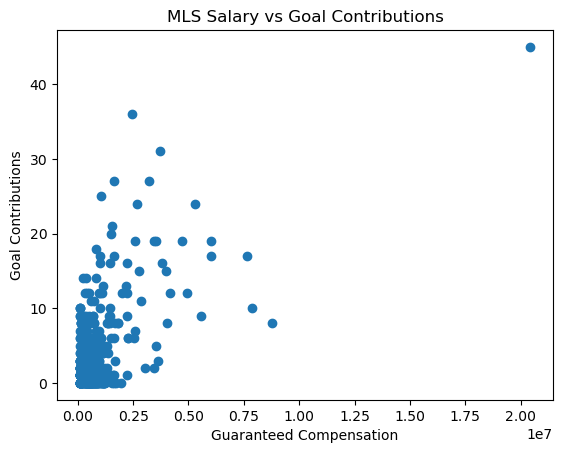

In [31]:
plt.scatter(analysis_df["Guaranteed Comp"], analysis_df["goal_contributions"])
plt.xlabel("Guaranteed Compensation")
plt.ylabel("Goal Contributions")
plt.title("MLS Salary vs Goal Contributions")
plt.show()

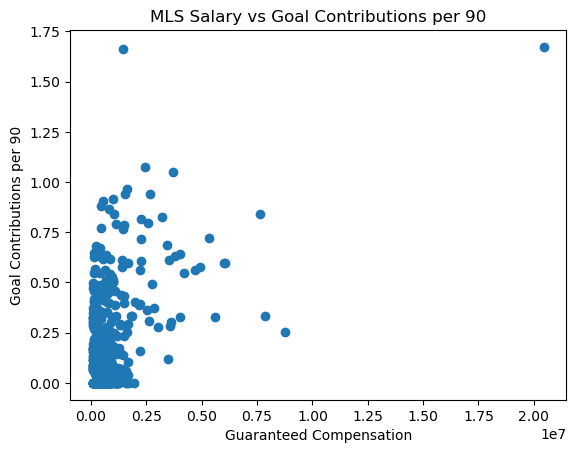

In [32]:
plt.scatter(analysis_df["Guaranteed Comp"], analysis_df["goal_contributions_per_90"])
plt.xlabel("Guaranteed Compensation")
plt.ylabel("Goal Contributions per 90")
plt.title("MLS Salary vs Goal Contributions per 90")
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

reg_df = analysis_df[[
    "Guaranteed Comp",
    "goal_contributions",
    "Min"
]].dropna()

X = reg_df[["goal_contributions", "Min"]]
y = reg_df["Guaranteed Comp"]

model = LinearRegression()
model.fit(X, y)

preds = model.predict(X)

print("Intercept:", model.intercept_)
print("Coefficients:")
print(pd.Series(model.coef_, index=X.columns))
print("R-squared:", r2_score(y, preds))

Intercept: 126953.0229917639
Coefficients:
goal_contributions    146748.680699
Min                       88.367253
dtype: float64
R-squared: 0.35441215717125407


In [34]:
top_contributors.to_csv("top_goal_contributors.csv", index=False)
top_per_90.to_csv("top_goal_contributors_per90.csv", index=False)
salary_efficiency.to_csv("best_salary_efficiency.csv", index=False)